# Imports

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
from kafka import  KafkaConsumer
from minio import Minio
import json
import os
from datetime import datetime
import io

kafka_config = {
    'bootstrap_servers': 'kafka1:9092',  # Update with your Kafka broker
    'serializer': lambda v: json.dumps(v).encode('utf-8'),  # Serialize data to JSON
    'deserializer': lambda v: json.loads(v.decode('utf-8'))  # Deserialize data from JSON
}



# Functions

In [2]:

def read_json_from_minio(minio_client, bucket, file_path):
    response = minio_client.get_object(bucket, file_path)
    data = json.load(response)
    return data

def json_to_df(data):
    return pd.DataFrame(data)

def list_files(minio_client, bucket, prefix):
    objects = minio_client.list_objects(bucket, prefix=prefix, recursive=True)
    return [obj.object_name for obj in objects]

def load_topic_dataframe(minio_client, bucket, topic):
    files = list_files(minio_client, bucket, f"data/{topic}/")
    
    df_list = []
    for file in files:
        data = read_json_from_minio(minio_client, bucket, file)
        df = json_to_df(data)
        df_list.append(df)

    return pd.concat(df_list, ignore_index=True)

In [3]:
# --- Configuration MinIO ---

class ConsumerManager:
    def __init__(self,config):
        self.minio_client = Minio(
            f"{os.getenv('minio_ip_address','localhost')}:3900",
            access_key=os.getenv("key_id"),
            secret_key=os.getenv("secret_key"),
            region="garage",
            secure=False
        )
        self.config = config
        self.bucket_name = os.getenv("bucket_name")
        self.consumers = {}

    def add_kafka_consumer(self, topic: str):
        print(f"Creating consumer for topic: {topic}")
        self.consumers[topic] = KafkaConsumer(
            topic,
            bootstrap_servers=self.config['bootstrap_servers'],
            value_deserializer=self.config['deserializer'],
            auto_offset_reset='earliest',
            enable_auto_commit=False,
            group_id=None,
            consumer_timeout_ms=5000,
        )
        print(f"Consumer created for {topic}")

    def upload_to_garage(self, topic: str, max_records: int = 5, timeout_ms: int = 5000):
        now = datetime.now()
        file_path = f"data/{topic}/batch_{now.strftime('%Y-%m-%d-%H%M%S')}.json"
        message_buffer = []

        records = self.consumers[topic].poll(timeout_ms=timeout_ms, max_records=max_records)
        total = sum(len(messages) for messages in records.values())
        print(f"Polled {total} message(s) from {topic}")

        for _, messages in records.items():
            for message in messages:
                message_buffer.append(message.value)
                print(message.value)

        if message_buffer:
            try:
                json_data = json.dumps(message_buffer).encode('utf-8')
                self.minio_client.put_object(
                    self.bucket_name,
                    file_path,
                    io.BytesIO(json_data),
                    length=len(json_data),
                    content_type='application/json'
                )
                print(f"[OK] {len(message_buffer)} messages sauvegardés dans : {file_path}")
            except Exception as e:
                print(f"[ERREUR] Impossible d'écrire dans MinIO : {e}")
        else:
            print(f"[INFO] Aucun message reçu pour le topic : {topic}")

# Data-reading

In [9]:
consumer_manager = ConsumerManager(kafka_config)

df_line_reports = load_topic_dataframe(
    consumer_manager.minio_client,
    consumer_manager.bucket_name,
    "line_reports"
)

# Structure of the DataFrame

DataFrame of shape (100, 5) where each row represents one document, and each cell contains structured JSON-like data

In [ ]:
df_line_reports.info()
df_line_reports.head()

Let's focus on cell (0, 0) and dive into the keys and values stored into the dataframe

In [ ]:
df = df_line_reports[0]
print(df[0])
print('_' * 10)
print(df[0].keys())
print('_' * 10)
print(df[0]['line'].keys())

{'line': {'id': 'line:IDFM:C01622', 'name': '4202', 'code': '4202', 'color': '82C8E6', 'text_color': '000000', 'codes': [{'type': 'Netex_PrivateCode', 'value': '400400407'}, {'type': 'source', 'value': 'FR1:Line:C01622:'}], 'physical_modes': [{'id': 'physical_mode:Bus', 'name': 'Bus', 'co2_emission_rate': {'value': 92.0, 'unit': 'gEC/Km'}}], 'commercial_mode': {'id': 'commercial_mode:Bus', 'name': 'Bus'}, 'network': {'id': 'network:IDFM:1080', 'name': 'Evry Centre Essonne', 'links': [], 'codes': [{'type': 'source', 'value': 'FR1:Network:1080:LOC'}]}, 'opening_time': '042100', 'closing_time': '001900', 'geojson': {'type': 'MultiLineString', 'coordinates': []}, 'links': [{'templated': False, 'rel': 'disruptions', 'internal': True, 'type': 'disruption', 'id': '326bc4d6-b0b0-11f0-aa04-0a58a9feac02'}]}, 'pt_objects': [{'id': 'network:IDFM:1080', 'name': 'Evry Centre Essonne', 'quality': 0, 'network': {'id': 'network:IDFM:1080', 'name': 'Evry Centre Essonne', 'links': [{'templated': False, '

Let's try to see the lines that our dataset is managing

In [102]:
import pandas as pd

# Liste pour stocker tous les DataFrames aplatis
df_list = []

for i in range(100):
    df = df_line_reports[i]  # chaque colonne de 100 cellules
    df_list.append(pd.json_normalize(df))

# Concaténer tous les DataFrames en un seul
df_flat = pd.concat(df_list, ignore_index=True)

# Maintenant tu peux sélectionner les colonnes désirées
df_flat[['line.name', 'line.network.name']].head()

,line.name,line.network.name
0,4202,Evry Centre Essonne
1,6502,Poissy - Les Mureaux
2,2108,Roissy Est
3,4156,Val d'Yerres Val de Seine
4,CDG VAL,ADP


In [117]:
all_cells = []

# Parcourir toutes les lignes et colonnes
for rowid in range(100):        # chaque "row" contient 100 cellules
    for cellid in range(5):               # chaque "cell" est un dict ou autre
        if isinstance(df_line_reports[rowid][cellid], dict): # ne garder que les dicts valides
            all_cells.append(df_line_reports[rowid][cellid])

print(f"Nombre total de cellules valides : {len(all_cells)}")

Nombre total de cellules valides : 482


Here we do a JOIN ON 'line.name'between the 'line' and the 'pt_objects' dataframe in order to see the network linked to the each stop.

In [126]:
import pandas as pd

# DataFrame lignes
rows_lines = []
for cell in all_cells:
    line = cell.get('line')
    if line:
        rows_lines.append({
            'line_name': line['name'],
            'network_name': line['network']['name'],
            'opening_time': line.get('opening_time'),
            'closing_time': line.get('closing_time'),
            'nb_disruptions': len(line.get('links', []))
        })

df_lines = pd.DataFrame(rows_lines)
print("line dataframe")
display(df_lines.head())

# DataFrame arrêts
rows_stops = []
for cell in all_cells:
    line = cell.get('line')
    if line:
        line_name = line['name']
        for obj in cell.get('pt_objects', []):
            if obj.get('embedded_type') == 'stop_area':
                stop_name = obj['stop_area']['name']
                rows_stops.append({
                    'line_name': line_name,
                    'stop_name': stop_name
                })

df_stops = pd.DataFrame(rows_stops)
print("stop dataframe")
display(df_stops.head())

# Jointure arrêts × lignes
df_stops_with_lines = df_stops.merge(
    df_lines,              # DataFrame des lignes
    on='line_name',        # clé commune
    how='left'             # LEFT JOIN style SQL
)
print('stop_df JOIN line_df ON line_name')
display(df_stops_with_lines.head())

line dataframe


,line_name,network_name,opening_time,closing_time,nb_disruptions
0,4202,Evry Centre Essonne,042100,001900,1
1,6502,Poissy - Les Mureaux,043500,001900,1
2,2108,Roissy Est,045600,203700,0
3,4156,Val d'Yerres Val de Seine,075900,081500,0
4,CDG VAL,ADP,000000,235959,0


stop dataframe


,line_name,stop_name
0,4202,Évry - Courcouronnes
1,CDG VAL,Aéroport CDG 1 (Terminal 3)
2,CDG VAL,Aéroport CDG - Terminal 2 (TGV)
3,N1,Aéroport CDG - Terminal 2 (TGV)
4,4204,Évry - Courcouronnes


stop_df JOIN line_df ON line_name


,line_name,stop_name,network_name,opening_time,closing_time,nb_disruptions
0,4202,Évry - Courcouronnes,Evry Centre Essonne,042100,001900,1
1,CDG VAL,Aéroport CDG 1 (Terminal 3),ADP,000000,235959,0
2,CDG VAL,Aéroport CDG - Terminal 2 (TGV),ADP,000000,235959,0
3,N1,Aéroport CDG - Terminal 2 (TGV),ADP,000000,235959,0
4,4204,Évry - Courcouronnes,Evry Centre Essonne,052200,225800,1


Let's see the kind of transport we have in thoses lines

<Axes: xlabel='0', ylabel='count'>

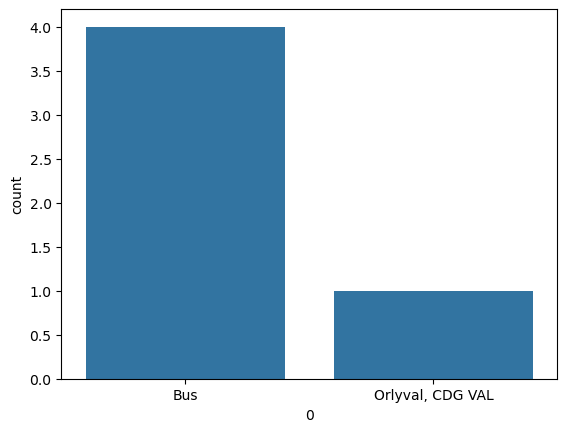

In [56]:
modes = df.apply(
    lambda x: x['line']['physical_modes'][0]['name']
)

sns.countplot(x=modes)

Let's try to find the number of stop from each lines in order to see which one is the largest.

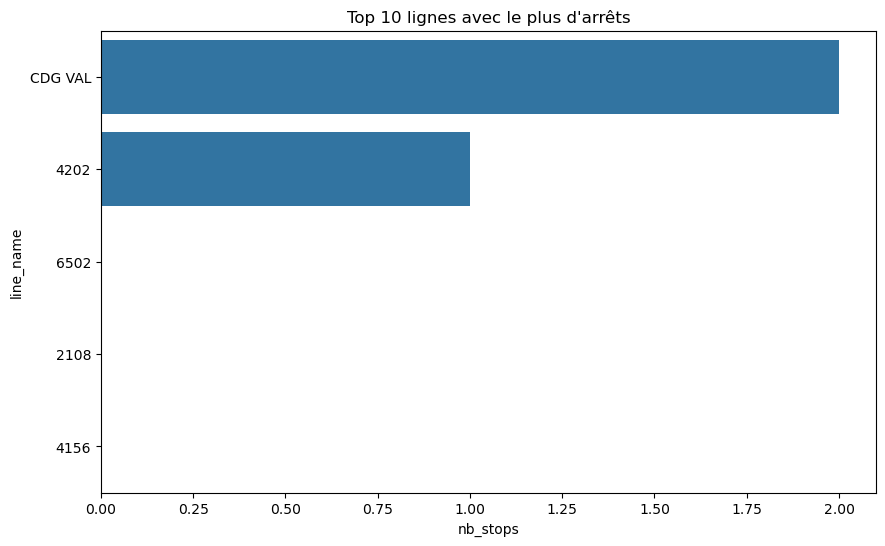

In [70]:
# Only validate the lines with a key 'line' inside
df_valid = df[df.apply(lambda x: 'line' in x)]

df_line_name = df_valid.apply(lambda x: x['line']['name'])

# exctract the numbers of stop inside each line
df_nb_stops = df_valid.apply(lambda x: sum(
    1 for obj in x['pt_objects'] if obj['embedded_type'] == 'stop_area'
))

df_clean = pd.DataFrame({
    'line_name': df_line_name,
    'nb_stops': df_nb_stops
})

# Top 10 lignes avec le plus d'arrêts
top_df = df_clean.sort_values(by='nb_stops', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='nb_stops', y='line_name', data=top_df)
plt.title("Top 10 lignes avec le plus d'arrêts")
plt.show()

Using SparkSQL DataFrame

In [73]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, size, expr
import copy

# df = ta Series originale
df_valid = df[df.apply(lambda x: 'line' in x)]

# convertir chaque élément en dict “pur” pour Spark
data_list = [copy.deepcopy(x) for x in df_valid.tolist()]

spark = SparkSession.builder.appName("LineStops").getOrCreate()

spark_df = spark.createDataFrame(data_list)
spark_df.printSchema()

# Créer une vue temporaire
spark_df.createOrReplaceTempView("lines")

# SparkSQL
top10_lines_sql = spark.sql("""
SELECT
    line.name AS line_name,
    SIZE(FILTER(pt_objects, x -> x.embedded_type = 'stop_area')) AS nb_stops
FROM lines
WHERE line IS NOT NULL
ORDER BY nb_stops DESC
LIMIT 10
""")

top10_lines_sql.show(truncate=False)


root
 |-- line: map (nullable = true)
 |    |-- key: string
 |    |-- value: string (valueContainsNull = true)
 |-- pt_objects: array (nullable = true)
 |    |-- element: map (containsNull = true)
 |    |    |-- key: string
 |    |    |-- value: string (valueContainsNull = true)

+---------+--------+
|line_name|nb_stops|
+---------+--------+
|CDG VAL  |2       |
|4202     |1       |
|4156     |0       |
|6502     |0       |
|2108     |0       |
+---------+--------+



Let's see for how long the lines are open (time between opening and closure)

In [86]:
# Extraire les lignes valides
df_valid = df_line_reports[0][df_line_reports[0].apply(lambda x: 'line' in x)]

# DataFrame propre avec line_name, opening_time et closing_time
df_times = pd.DataFrame({
    'line_name': df_valid.apply(lambda x: x['line']['name']),
    'opening_time': pd.to_datetime(df_valid.apply(lambda x: x['line']['opening_time']), format='%H%M%S'),
    'closing_time': pd.to_datetime(df_valid.apply(lambda x: x['line']['closing_time']), format='%H%M%S')
})

# Durée de service
df_times['duration'] = df_times['closing_time'] - df_times['opening_time']

# Si duration < 0 → ajouter 1 jour
df_times['duration'] = df_times['duration'].apply(lambda x: x if x.total_seconds() >= 0 else x + pd.Timedelta(days=1))

df_times['duration_hours'] = df_times['duration'].dt.total_seconds() / 3600

print(df_times[['line_name', 'duration', 'duration_hours']])

  line_name        duration  duration_hours
0      4202 0 days 19:58:00       19.966667
1      6502 0 days 19:44:00       19.733333
2      2108 0 days 15:41:00       15.683333
3      4156 0 days 00:16:00        0.266667
4   CDG VAL 0 days 23:59:59       23.999722
